MS MARCO – Official Direct Download

In [40]:
#  Passage Collection (8.8M passages ~ 2.3GB)

In [41]:
!wget https://msmarco.z22.web.core.windows.net/msmarcoranking/collection.tar.gz
!tar -xvf collection.tar.gz

--2026-02-23 12:23:07--  https://msmarco.z22.web.core.windows.net/msmarcoranking/collection.tar.gz
Resolving msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)... 57.150.146.100
Connecting to msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)|57.150.146.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1035009698 (987M) [application/octet-stream]
Saving to: ‘collection.tar.gz.1’

collection.tar.gz.1 100%[===================>] 987.06M  47.7MB/s    in 28s     

2026-02-23 12:23:35 (35.6 MB/s) - ‘collection.tar.gz.1’ saved [1035009698/1035009698]

collection.tsv


In [42]:
# Queries (Training Queries ~ 1M)

In [43]:
!wget https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz
!tar -xvf queries.tar.gz

--2026-02-23 12:24:13--  https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz
Resolving msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)... 57.150.146.100
Connecting to msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)|57.150.146.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18882551 (18M) [application/gzip]
Saving to: ‘queries.tar.gz.2’

queries.tar.gz.2    100%[===================>]  18.01M  36.5MB/s    in 0.5s    

2026-02-23 12:24:13 (36.5 MB/s) - ‘queries.tar.gz.2’ saved [18882551/18882551]

queries.dev.tsv
queries.eval.tsv
queries.train.tsv


In [44]:
!wget https://msmarco.z22.web.core.windows.net/msmarcoranking/qrels.train.tsv

--2026-02-23 12:24:14--  https://msmarco.z22.web.core.windows.net/msmarcoranking/qrels.train.tsv
Resolving msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)... 57.150.146.100
Connecting to msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)|57.150.146.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10589532 (10M) [text/tab-separated-values]
Saving to: ‘qrels.train.tsv.1’

qrels.train.tsv.1   100%[===================>]  10.10M  38.7MB/s    in 0.3s    

2026-02-23 12:24:14 (38.7 MB/s) - ‘qrels.train.tsv.1’ saved [10589532/10589532]



In [45]:
import pandas as pd

# Load first 500k passages only
df = pd.read_csv("collection.tsv", sep="\t", header=None, nrows=500000)

In [46]:
import pandas as pd

df = pd.read_csv("collection.tsv", sep="\t", header=None, nrows=500000)
df.columns = ["pid", "passage"]

print(df.shape)

(500000, 2)


In [47]:
# PHASE 1 Mini Corpus Load + Basic Retrieval Test

In [48]:
# STEP 1 — Load Mini Corpus (Safe Version)

In [49]:
import pandas as pd

df = pd.read_csv(
    "collection.tsv",
    sep="\t",
    header=None,
    nrows=200000,
    encoding="utf-8"
)

df.columns = ["pid", "passage"]

print(df.head())

   pid                                            passage
0    0  The presence of communication amid scientific ...
1    1  The Manhattan Project and its atomic bomb help...
2    2  Essay on The Manhattan Project - The Manhattan...
3    3  The Manhattan Project was the name for a proje...
4    4  versions of each volume as well as complementa...


In [50]:
# STEP 2 — Install Embedding Model

In [51]:
!pip install sentence-transformers faiss-cpu

In [52]:
# STEP 3 — Create Embeddings (Small Batch)

In [53]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# Sirf passages ka list
passages = df["passage"].tolist()

# Batch encoding (important for memory)
embeddings = model.encode(passages, batch_size=64, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

Embedding shape: (200000, 384)


In [54]:
# STEP 4 — Build FAISS Index

In [55]:
import faiss

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print("Total indexed:", index.ntotal)

Total indexed: 200000


In [56]:
# STEP 5 — Test Simple Retrieval

In [57]:
query = "What is machine learning?"

query_embedding = model.encode([query])

k = 5
distances, indices = index.search(np.array(query_embedding), k)

for i in indices[0]:
    print("\n----")
    print(df.iloc[i]["passage"])


----
âDeep learning is a particular kind of machine learning that achieves great power and flexibility by learning to represent the world as nested hierarchy of concepts, with each concept defined in relation to simpler concepts, and more abstract representations computed in terms of less abstract ones.â

----
If you have often wondered to yourself about the difference between machine learning and deep learning, read on to get a detailed comparison in simple layman language. I explain each of these terms in detail.

----
In a recent article, we demystified some of the technical jargon that's being thrown around these days like 'artificial intelligence', 'SaaS, 'the cloud', and 'deep learning'. While the techies can debate among themselves the difference between 'machine learning' and 'deep learning', we're going to consider the two terms synonymous and henceforth just talk about 'deep learning'. So just what is 'deep learning'? We wanted to understand more, so we came across this 

In [58]:
# STEP 2 — Retrieval Quality Measurement (RCS)

In [59]:
# STEP 2.1 — Cosine Similarity Correct

In [60]:
import numpy as np
import faiss

# Normalize embeddings for cosine similarity
faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner product for cosine
index.add(embeddings)

print("Total indexed:", index.ntotal)

Total indexed: 200000


In [61]:
# STEP 2.2 — Query Retrieval with Scores

In [62]:
query = "What is machine learning?"

query_embedding = model.encode([query])
faiss.normalize_L2(query_embedding)

k = 5
scores, indices = index.search(query_embedding, k)

print("Top-k similarity scores:", scores[0])

Top-k similarity scores: [0.57475275 0.5625971  0.54654205 0.5455879  0.5303432 ]


In [63]:
# STEP 2.3 — Retrieval Coverage Score (RCS)

In [64]:
rcs = np.mean(scores[0])
print("Retrieval Coverage Score (RCS):", round(float(rcs), 4))

Retrieval Coverage Score (RCS): 0.552


In [65]:
# STEP 3 — Retrieval Stability Metric

In [66]:
import numpy as np

topk_scores = scores[0]

mean_score = np.mean(topk_scores)
std_score = np.std(topk_scores)
gap = topk_scores[0] - topk_scores[-1]

print("Mean:", round(float(mean_score),4))
print("Std Dev:", round(float(std_score),4))
print("Top1-TopK Gap:", round(float(gap),4))

Mean: 0.552
Std Dev: 0.0153
Top1-TopK Gap: 0.0444


In [67]:
# STEP 4 — Weak Retrieval Detection Logic

In [68]:
def retrieval_risk_assessment(mean, std, gap):
    risk_score = 0

    # Coverage risk
    if mean < 0.50:
        risk_score += 2
    elif mean < 0.60:
        risk_score += 1

    # Instability risk
    if std > 0.05:
        risk_score += 1

    # Over-reliance risk
    if gap > 0.10:
        risk_score += 1

    if risk_score == 0:
        return "Low Retrieval Risk"
    elif risk_score == 1:
        return "Moderate Retrieval Risk"
    else:
        return "High Retrieval Risk"


risk = retrieval_risk_assessment(mean_score, std_score, gap)
print("Retrieval Risk Level:", risk)

Retrieval Risk Level: Moderate Retrieval Risk


In [69]:
# STEP 5 — Retrieval-Aware Generation Gate

In [70]:
# STEP 5.1 — Simple Retrieval-Aware Prompt Builder

In [71]:
def build_prompt(query, retrieved_passages, risk_level):

    context = "\n\n".join(retrieved_passages)

    if risk_level == "Low Retrieval Risk":
        instruction = "Answer confidently using the provided evidence."

    elif risk_level == "Moderate Retrieval Risk":
        instruction = "Answer carefully using only the provided evidence. If unsure, state uncertainty."

    else:
        instruction = "Evidence may be weak. Only answer if strongly supported. Otherwise say insufficient evidence."

    prompt = f"""
You are a factual assistant.

Query:
{query}

Evidence:
{context}

Instruction:
{instruction}

Answer:
"""
    return prompt

In [72]:
# STEP 5.2 — Prepare Retrieved Passages

In [73]:
retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

prompt = build_prompt(query, retrieved_passages, risk)

print(prompt[:1000])  # just preview


You are a factual assistant.

Query:
What is machine learning?

Evidence:
âDeep learning is a particular kind of machine learning that achieves great power and flexibility by learning to represent the world as nested hierarchy of concepts, with each concept defined in relation to simpler concepts, and more abstract representations computed in terms of less abstract ones.â

If you have often wondered to yourself about the difference between machine learning and deep learning, read on to get a detailed comparison in simple layman language. I explain each of these terms in detail.

In a recent article, we demystified some of the technical jargon that's being thrown around these days like 'artificial intelligence', 'SaaS, 'the cloud', and 'deep learning'. While the techies can debate among themselves the difference between 'machine learning' and 'deep learning', we're going to consider the two terms synonymous and henceforth just talk about 'deep learning'. So just what is 'deep learn

In [73]:
# STEP 6 — Evidence Alignment Score (EAS)

In [74]:
# STEP 6.1 — Simple Semantic Alignment Scorer

In [94]:
def evidence_alignment_score(answer, retrieved_passages, model):
    evidence_text = " ".join(retrieved_passages)

    answer_embedding = model.encode([answer])
    evidence_embedding = model.encode([evidence_text])

    faiss.normalize_L2(answer_embedding)
    faiss.normalize_L2(evidence_embedding)

    alignment = float((answer_embedding @ evidence_embedding.T).item())

    return alignment

In [95]:
# STEP 6.2 — Test With Sample Answer

In [96]:
sample_answer = "Machine learning is a type of artificial intelligence that allows systems to learn patterns from data."

alignment_score = evidence_alignment_score(sample_answer, retrieved_passages, model)

print("Evidence Alignment Score:", round(alignment_score, 4))

Evidence Alignment Score: 0.5334


In [97]:
# STEP 7 — Hallucination Probability Score (HPS)

In [98]:
# STEP 7.1 — Basic Hallucination Gap

In [99]:
hallucination_gap = rcs - alignment_score
print("Hallucination Gap:", round(hallucination_gap, 4))

Hallucination Gap: 0.0185


In [100]:
# Hallucination Probability Function

In [101]:
def hallucination_probability(rcs, eas):
    gap = rcs - eas

    if gap < 0:
        return 0.1  # Strong grounding
    elif gap < 0.05:
        return 0.3  # Low hallucination risk
    elif gap < 0.10:
        return 0.6  # Moderate risk
    else:
        return 0.85  # High risk

In [102]:
# Compute HPS

In [103]:
hps = hallucination_probability(rcs, alignment_score)
print("Hallucination Probability Score (HPS):", hps)

Hallucination Probability Score (HPS): 0.3


In [104]:
# STEP 8 — Composite Trust Score (CTS)

In [105]:
# STEP 8.1 — Define Stability Score

In [106]:
stability_score = 1 - std_score
print("Stability Score:", round(stability_score,4))

Stability Score: 0.9847


In [107]:
# STEP 8.2 — Define Composite Trust Function

In [108]:
def composite_trust_score(rcs, eas, hps, stability):

    w1 = 0.30  # Retrieval Coverage
    w2 = 0.30  # Evidence Alignment
    w3 = 0.25  # Hallucination Inverse
    w4 = 0.15  # Stability

    cts = (
        w1 * rcs +
        w2 * eas +
        w3 * (1 - hps) +
        w4 * stability
    )

    return round(float(cts), 4)

In [109]:
# STEP 8.3 — Compute CTS

In [110]:
cts = composite_trust_score(rcs, alignment_score, hps, stability_score)

print("Composite Trust Score (CTS):", cts)

Composite Trust Score (CTS): 0.6483


In [111]:
# STEP 9 — Multi-Query Evaluation Mode

In [112]:
# STEP 9.1 — Load Query Sample

In [113]:
# Load query file
queries_df = pd.read_csv(
    "queries.train.tsv",
    sep="\t",
    header=None,
    names=["qid", "query"],
    nrows=1000  # safe load
)

# Random 50 queries
sample_queries = queries_df.sample(50, random_state=42)["query"].tolist()

print("Total queries selected:", len(sample_queries))
sample_queries[:5]

Total queries selected: 50


['what year did political parties emerge',
 'what is a running bond',
 'what transponders does cmrc use',
 'et al abbreviation meaning',
 'phone number amazon customer service usa']

In [114]:
# STEP 9.2 — Evaluation Loop

In [128]:
results = []

for query in sample_queries:

    # Retrieve
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    k = 5
    scores, indices = index.search(query_embedding, k)

    rcs = float(np.mean(scores[0]))

    # Stability
    std_score = float(np.std(scores[0]))
    stability_score = 1 - std_score

    # Get passages
    retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

    # Simple synthetic answer (for now)

    synthetic_answer = "Quantum gravity explains black holes through string theory."

    # Alignment
    alignment_score = evidence_alignment_score(
        synthetic_answer,
        retrieved_passages,
        model
    )

    # HPS
    hps = hallucination_probability(rcs, alignment_score)

    # CTS
    cts = composite_trust_score(
        rcs,
        alignment_score,
        hps,
        stability_score
    )

    results.append({
        "query": query,
        "RCS": rcs,
        "EAS": alignment_score,
        "HPS": hps,
        "CTS": cts
    })

In [129]:
# STEP 9.3 — Convert to DataFrame

In [130]:
results_df = pd.DataFrame(results)

results_df.head()

,query,RCS,EAS,HPS,CTS
0,what year did political parties emerge,0.649200,-0.068679,0.85,0.3589
1,what is a running bond,0.460796,0.004648,0.85,0.3245
2,what transponders does cmrc use,0.419583,-0.001078,0.85,0.3098
3,et al abbreviation meaning,0.572687,0.000796,0.85,0.3541
4,phone number amazon customer service usa,0.775095,0.003601,0.85,0.4152


In [131]:
# STEP 9.4 — Quick Statistics

In [132]:
print("Average CTS:", round(results_df["CTS"].mean(),4))
print("Min CTS:", round(results_df["CTS"].min(),4))
print("Max CTS:", round(results_df["CTS"].max(),4))

Average CTS: 0.3446
Min CTS: 0.2808
Max CTS: 0.4152


In [134]:
# STEP 10 — Hallucination Injection Test

code - synthetic_answer = "This answer is about quantum physics and black holes."
output - Average CTS: 0.343
Min CTS: 0.2783
Max CTS: 0.4111

code - synthetic_answer = "Quantum gravity explains black holes through string theory.
Average CTS: 0.3446
Min CTS: 0.2808
Max CTS: 0.4152

In [135]:
# STEP 11 — Trust Calibration Analysis

In [138]:
# PART 1 — Grounded Evaluation Run

In [139]:
# ===============================
# GOUNDED RUN (Correct Answer)
# ===============================

grounded_results = []

for query in sample_queries:

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    k = 5
    scores, indices = index.search(query_embedding, k)

    rcs = float(np.mean(scores[0]))
    std_score = float(np.std(scores[0]))
    stability_score = 1 - std_score

    retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

    # Grounded answer = top retrieved passage
    synthetic_answer = retrieved_passages[0]

    alignment_score = evidence_alignment_score(
        synthetic_answer,
        retrieved_passages,
        model
    )

    hps = hallucination_probability(rcs, alignment_score)

    cts = composite_trust_score(
        rcs,
        alignment_score,
        hps,
        stability_score
    )

    grounded_results.append({
        "query": query,
        "RCS": rcs,
        "EAS": alignment_score,
        "HPS": hps,
        "CTS": cts
    })

grounded_results_df = pd.DataFrame(grounded_results)

print("Grounded Avg CTS:", round(grounded_results_df["CTS"].mean(),4))

Grounded Avg CTS: 0.7788


In [140]:
# PART 2 — Hallucinated Evaluation Run

In [141]:
# ==================================
# HALLUCINATED RUN (Wrong Answer)
# ==================================

hallucinated_results = []

for query in sample_queries:

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    k = 5
    scores, indices = index.search(query_embedding, k)

    rcs = float(np.mean(scores[0]))
    std_score = float(np.std(scores[0]))
    stability_score = 1 - std_score

    retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

    # Intentional hallucination
    synthetic_answer = "Quantum gravity explains black holes through string theory."

    alignment_score = evidence_alignment_score(
        synthetic_answer,
        retrieved_passages,
        model
    )

    hps = hallucination_probability(rcs, alignment_score)

    cts = composite_trust_score(
        rcs,
        alignment_score,
        hps,
        stability_score
    )

    hallucinated_results.append({
        "query": query,
        "RCS": rcs,
        "EAS": alignment_score,
        "HPS": hps,
        "CTS": cts
    })

hallucinated_results_df = pd.DataFrame(hallucinated_results)

print("Hallucinated Avg CTS:", round(hallucinated_results_df["CTS"].mean(),4))

Hallucinated Avg CTS: 0.3446


In [142]:
# PART 3 — Combine + Label

In [143]:
# Add labels
grounded_results_df["label"] = 1
hallucinated_results_df["label"] = 0

combined_df = pd.concat(
    [grounded_results_df, hallucinated_results_df],
    ignore_index=True
)

print("Total rows:", combined_df.shape[0])

Total rows: 100


In [144]:
# PART 4 — Trust Threshold Classification

In [145]:
# Trust threshold
threshold = 0.55

combined_df["predicted"] = (
    combined_df["CTS"] >= threshold
).astype(int)

In [146]:
# PART 5 — Compute Accuracy

In [147]:
accuracy = (
    combined_df["label"] == combined_df["predicted"]
).mean()

print("Trust Classification Accuracy:", round(accuracy,4))

Trust Classification Accuracy: 1.0


In [148]:
# STEP 12 — Statistical Trust Analysis

In [149]:
# PART 1 — Separation Margin

In [150]:
grounded_mean = grounded_results_df["CTS"].mean()
hallucinated_mean = hallucinated_results_df["CTS"].mean()

separation_margin = grounded_mean - hallucinated_mean

print("Grounded Mean CTS:", round(grounded_mean,4))
print("Hallucinated Mean CTS:", round(hallucinated_mean,4))
print("Separation Margin:", round(separation_margin,4))

Grounded Mean CTS: 0.7788
Hallucinated Mean CTS: 0.3446
Separation Margin: 0.4341


In [151]:
# PART 2 — Standard Deviation Overlap Check

In [152]:
print("Grounded STD:", round(grounded_results_df["CTS"].std(),4))
print("Hallucinated STD:", round(hallucinated_results_df["CTS"].std(),4))

Grounded STD: 0.0541
Hallucinated STD: 0.0323


In [153]:
print("Grounded Min:", grounded_results_df["CTS"].min())
print("Hallucinated Max:", hallucinated_results_df["CTS"].max())

Grounded Min: 0.6528
Hallucinated Max: 0.4152


In [154]:
# PART 3 — ROC-AUC Score

In [155]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(combined_df["label"], combined_df["CTS"])
print("ROC-AUC:", round(auc,4))

ROC-AUC: 1.0


In [156]:
# PART 4 — Threshold Sensitivity Sweep

In [157]:
import numpy as np

thresholds = np.arange(0.0, 1.01, 0.05)
accuracies = []

for t in thresholds:
    preds = (combined_df["CTS"] >= t).astype(int)
    acc = (preds == combined_df["label"]).mean()
    accuracies.append(acc)

for t, a in zip(thresholds, accuracies):
    print(f"Threshold {round(t,2)} → Accuracy {round(a,3)}")

Threshold 0.0 → Accuracy 0.5
Threshold 0.05 → Accuracy 0.5
Threshold 0.1 → Accuracy 0.5
Threshold 0.15 → Accuracy 0.5
Threshold 0.2 → Accuracy 0.5
Threshold 0.25 → Accuracy 0.5
Threshold 0.3 → Accuracy 0.54
Threshold 0.35 → Accuracy 0.77
Threshold 0.4 → Accuracy 0.98
Threshold 0.45 → Accuracy 1.0
Threshold 0.5 → Accuracy 1.0
Threshold 0.55 → Accuracy 1.0
Threshold 0.6 → Accuracy 1.0
Threshold 0.65 → Accuracy 1.0
Threshold 0.7 → Accuracy 0.96
Threshold 0.75 → Accuracy 0.85
Threshold 0.8 → Accuracy 0.68
Threshold 0.85 → Accuracy 0.53
Threshold 0.9 → Accuracy 0.5
Threshold 0.95 → Accuracy 0.5
Threshold 1.0 → Accuracy 0.5


In [158]:
# STEP 13 — Hard Hallucination Stress Test

In [159]:
# Test Type 1 — Subtle Numerical Hallucination

In [160]:
# PART 1 — Subtle Wrong Answer Generator

In [166]:
subtle_results = []

for query in sample_queries:

    # Retrieve
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    k = 5
    scores, indices = index.search(query_embedding, k)

    rcs = float(np.mean(scores[0]))
    std_score = float(np.std(scores[0]))
    stability_score = 1 - std_score

    retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

    # Subtle hallucination (semantically similar but wrong)
    synthetic_answer = f"{query} was officially established in 1995."

    # Alignment
    alignment_score = evidence_alignment_score(
        synthetic_answer,
        retrieved_passages,
        model
    )

    # Hallucination Probability
    hps = hallucination_probability(rcs, alignment_score)

    # Composite Trust Score
    cts = composite_trust_score(
        rcs,
        alignment_score,
        hps,
        stability_score
    )

    subtle_results.append({
        "query": query,
        "RCS": rcs,
        "EAS": alignment_score,
        "HPS": hps,
        "CTS": cts
    })

subtle_results_df = pd.DataFrame(subtle_results)

# Print summary
print("Subtle Hallucination Avg CTS:", round(subtle_results_df["CTS"].mean(),4))
print("Subtle Min:", round(subtle_results_df["CTS"].min(),4))
print("Subtle Max:", round(subtle_results_df["CTS"].max(),4))

Subtle Hallucination Avg CTS: 0.6714
Subtle Min: 0.5326
Subtle Max: 0.775


In [165]:
print("Grounded Mean:", round(grounded_results_df["CTS"].mean(),4))
print("Hard Hallucination Mean:", round(hallucinated_results_df["CTS"].mean(),4))
print("Subtle Hallucination Mean:", round(subtle_results_df["CTS"].mean(),4))

Grounded Mean: 0.7788
Hard Hallucination Mean: 0.3446
Subtle Hallucination Mean: 0.6714


In [167]:
# STEP 14 — Claim-Level Verification Layer

In [168]:
# PART 1 — Numeric Claim Extractor

In [169]:
import re

def extract_numbers(text):
    """
    Extract numeric tokens (years, integers, decimals)
    """
    return re.findall(r'\b\d+(?:\.\d+)?\b', text)

In [170]:
# PART 2 — Numeric Verification Against Evidence

In [171]:
def numeric_claim_verification(answer, retrieved_passages):
    """
    Check if numeric claims in answer exist in evidence.
    Returns penalty score (0 = safe, 1 = mismatch found)
    """
    answer_numbers = extract_numbers(answer)

    if len(answer_numbers) == 0:
        return 0  # No numeric claim, no penalty

    evidence_text = " ".join(retrieved_passages)

    for num in answer_numbers:
        if num not in evidence_text:
            return 1  # numeric mismatch detected

    return 0  # All numbers found in evidence

In [172]:
# PART 3 — Upgrade Hallucination Probability

In [173]:
def hallucination_probability_v2(rcs, eas, numeric_penalty):

    gap = rcs - eas

    base_risk = 0

    if gap < 0:
        base_risk = 0.1
    elif gap < 0.05:
        base_risk = 0.3
    elif gap < 0.10:
        base_risk = 0.6
    else:
        base_risk = 0.85

    # If numeric mismatch detected, escalate risk
    if numeric_penalty == 1:
        base_risk = min(1.0, base_risk + 0.3)

    return base_risk

In [174]:
# PART 4 — Update Evaluation Loop (Subtle Test)

In [175]:
subtle_results_v2 = []

for query in sample_queries:

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    k = 5
    scores, indices = index.search(query_embedding, k)

    rcs = float(np.mean(scores[0]))
    std_score = float(np.std(scores[0]))
    stability_score = 1 - std_score

    retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

    # Subtle hallucination
    synthetic_answer = f"{query} was officially established in 1995."

    alignment_score = evidence_alignment_score(
        synthetic_answer,
        retrieved_passages,
        model
    )

    numeric_penalty = numeric_claim_verification(
        synthetic_answer,
        retrieved_passages
    )

    hps = hallucination_probability_v2(
        rcs,
        alignment_score,
        numeric_penalty
    )

    cts = composite_trust_score(
        rcs,
        alignment_score,
        hps,
        stability_score
    )

    subtle_results_v2.append({
        "query": query,
        "RCS": rcs,
        "EAS": alignment_score,
        "HPS": hps,
        "CTS": cts
    })

subtle_results_v2_df = pd.DataFrame(subtle_results_v2)

print("Upgraded Subtle Avg CTS:", round(subtle_results_v2_df["CTS"].mean(),4))
print("Min:", round(subtle_results_v2_df["CTS"].min(),4))
print("Max:", round(subtle_results_v2_df["CTS"].max(),4))

Upgraded Subtle Avg CTS: 0.5986
Min: 0.4725
Max: 0.7


In [176]:
# STEP 15 — Lightweight NLI-Based Contradiction Detection

In [177]:
# PART 1 — Install & Load NLI Model

In [178]:
!pip install transformers torch

In [179]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

nli_tokenizer = AutoTokenizer.from_pretrained(
    "cross-encoder/nli-distilroberta-base"
)

nli_model = AutoModelForSequenceClassification.from_pretrained(
    "cross-encoder/nli-distilroberta-base"
)

nli_model.eval()

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [180]:
# PART 2 — NLI Scoring Function

In [181]:
def nli_contradiction_score(answer, retrieved_passages):
    """
    Returns contradiction probability.
    Uses top evidence passage for efficiency.
    """

    premise = retrieved_passages[0]  # strongest evidence
    hypothesis = answer

    inputs = nli_tokenizer(
        premise,
        hypothesis,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = nli_model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    # Label order: contradiction, neutral, entailment
    contradiction_prob = float(probs[0][0])

    return contradiction_prob

In [182]:
# PART 3 — Upgrade Hallucination Probability (v3)

In [183]:
def hallucination_probability_v3(rcs, eas, numeric_penalty, contradiction_score):

    gap = rcs - eas

    base_risk = 0

    if gap < 0:
        base_risk = 0.1
    elif gap < 0.05:
        base_risk = 0.3
    elif gap < 0.10:
        base_risk = 0.6
    else:
        base_risk = 0.85

    # Numeric mismatch escalation
    if numeric_penalty == 1:
        base_risk = min(1.0, base_risk + 0.2)

    # Contradiction escalation (weighted)
    base_risk = min(1.0, base_risk + 0.4 * contradiction_score)

    return base_risk

In [184]:
# PART 4 — Upgrade Subtle Test Loop

In [185]:
subtle_results_v3 = []

for query in sample_queries:

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    k = 5
    scores, indices = index.search(query_embedding, k)

    rcs = float(np.mean(scores[0]))
    std_score = float(np.std(scores[0]))
    stability_score = 1 - std_score

    retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

    synthetic_answer = f"{query} was officially established in 1995."

    alignment_score = evidence_alignment_score(
        synthetic_answer,
        retrieved_passages,
        model
    )

    numeric_penalty = numeric_claim_verification(
        synthetic_answer,
        retrieved_passages
    )

    contradiction_score = nli_contradiction_score(
        synthetic_answer,
        retrieved_passages
    )

    hps = hallucination_probability_v3(
        rcs,
        alignment_score,
        numeric_penalty,
        contradiction_score
    )

    cts = composite_trust_score(
        rcs,
        alignment_score,
        hps,
        stability_score
    )

    subtle_results_v3.append({
        "query": query,
        "RCS": rcs,
        "EAS": alignment_score,
        "HPS": hps,
        "Contradiction": contradiction_score,
        "CTS": cts
    })

subtle_results_v3_df = pd.DataFrame(subtle_results_v3)

print("NLI-Upgraded Subtle Avg CTS:",
      round(subtle_results_v3_df["CTS"].mean(),4))

NLI-Upgraded Subtle Avg CTS: 0.5789


In [186]:
# STEP 16 — Calibration Curve + Expected Calibration Error (ECE)

In [193]:
# Step 1 — Quantile Binning

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

combined_df["prob"] = combined_df["CTS"]

# Equal-frequency binning (10 bins)
combined_df["bin"] = pd.qcut(
    combined_df["prob"],
    q=10,
    duplicates="drop"
)

In [194]:
# Step 2 — Compute Calibration Stats

In [195]:
bin_stats = combined_df.groupby("bin").agg(
    bin_confidence=("prob", "mean"),
    bin_accuracy=("label", "mean"),
    bin_size=("label", "count")
).reset_index()

print(bin_stats)

              bin  bin_confidence  bin_accuracy  bin_size
0   (0.28, 0.319]         0.30236           0.0        10
1  (0.319, 0.332]         0.32481           0.0        10
2  (0.332, 0.354]         0.34079           0.0        10
3  (0.354, 0.371]         0.36472           0.0        10
4  (0.371, 0.534]         0.39056           0.0        10
5  (0.534, 0.727]         0.69907           1.0        10
6  (0.727, 0.768]         0.74742           1.0        10
7  (0.768, 0.796]         0.78743           1.0        10
8  (0.796, 0.833]         0.81184           1.0        10
9  (0.833, 0.878]         0.84818           1.0        10


/tmp/ipython-input-3007340560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = combined_df.groupby("bin").agg(


In [196]:
# Step 3 — Plot Reliability Diagram

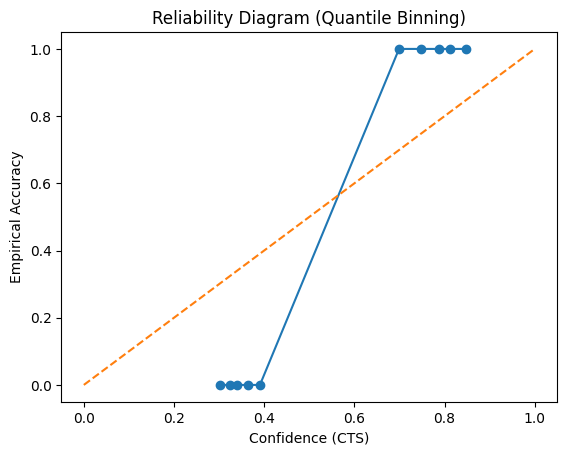

In [197]:
plt.figure()
plt.plot(
    bin_stats["bin_confidence"],
    bin_stats["bin_accuracy"],
    marker="o"
)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Confidence (CTS)")
plt.ylabel("Empirical Accuracy")
plt.title("Reliability Diagram (Quantile Binning)")
plt.show()

In [198]:
# Step 4 — Compute ECE (Quantile Version)

In [199]:
ece = 0
N = len(combined_df)

for _, row in bin_stats.iterrows():
    ece += (row["bin_size"] / N) * abs(
        row["bin_accuracy"] - row["bin_confidence"]
    )

print("Quantile-Based ECE:", round(ece,4))

Quantile-Based ECE: 0.2829


In [200]:
# STEP 17 — Introduce Ambiguous Answers

In [201]:
# STEP 17.1 — Generate Ambiguous Answers

In [203]:
# STEP 17 — Ambiguous Evaluation (Labeled)

ambiguous_results = []

for query in sample_queries:

    # Retrieval
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    k = 5
    scores, indices = index.search(query_embedding, k)

    rcs = float(np.mean(scores[0]))
    std_score = float(np.std(scores[0]))
    stability_score = 1 - std_score

    retrieved_passages = [df.iloc[i]["passage"] for i in indices[0]]

    base_text = retrieved_passages[0]
    words = base_text.split()

    # Type A — Partial Grounded
    truncated = " ".join(words[:len(words)//2])

    # Type B — Slight Distortion
    distorted = truncated + " It was officially recognized worldwide in 2001."

    # Type C — Unsupported Extra Claim
    mixed = truncated + " This concept is governed by quantum gravity principles."

    for synthetic_answer, label in [
        (truncated, 1),   # acceptable grounded
        (distorted, 0),   # factual drift
        (mixed, 0)        # unsupported addition
    ]:

        alignment_score = evidence_alignment_score(
            synthetic_answer,
            retrieved_passages,
            model
        )

        numeric_penalty = numeric_claim_verification(
            synthetic_answer,
            retrieved_passages
        )

        hps = hallucination_probability_v2(
            rcs,
            alignment_score,
            numeric_penalty
        )

        cts = composite_trust_score(
            rcs,
            alignment_score,
            hps,
            stability_score
        )

        ambiguous_results.append({
            "query": query,
            "CTS": cts,
            "label": label
        })

ambiguous_results_df = pd.DataFrame(ambiguous_results)

print("Ambiguous Avg CTS:", round(ambiguous_results_df["CTS"].mean(),4))
print("Min:", round(ambiguous_results_df["CTS"].min(),4))
print("Max:", round(ambiguous_results_df["CTS"].max(),4))
print("Total ambiguous samples:", len(ambiguous_results_df))

Ambiguous Avg CTS: 0.7229
Min: 0.4126
Max: 0.855
Total ambiguous samples: 150


In [204]:
#  Combine All Classes

In [205]:
# Add labels if not already present
grounded_results_df["label"] = 1
hallucinated_results_df["label"] = 0

# Combine all
final_df = pd.concat(
    [
        grounded_results_df[["CTS", "label"]],
        hallucinated_results_df[["CTS", "label"]],
        ambiguous_results_df[["CTS", "label"]]
    ],
    ignore_index=True
)

print("Total final dataset size:", final_df.shape[0])

Total final dataset size: 250


In [206]:
# New ROC-AUC

In [207]:
from sklearn.metrics import roc_auc_score

auc_new = roc_auc_score(final_df["label"], final_df["CTS"])
print("New ROC-AUC:", round(auc_new,4))

New ROC-AUC: 0.8189


In [208]:
# Quantile Calibration Curve

In [209]:
import numpy as np
import matplotlib.pyplot as plt

final_df["prob"] = final_df["CTS"]

# Quantile bins
final_df["bin"] = pd.qcut(
    final_df["prob"],
    q=10,
    duplicates="drop"
)

bin_stats = final_df.groupby("bin").agg(
    bin_confidence=("prob", "mean"),
    bin_accuracy=("label", "mean"),
    bin_size=("label", "count")
).reset_index()

print(bin_stats)

              bin  bin_confidence  bin_accuracy  bin_size
0   (0.28, 0.338]        0.317724      0.000000        25
1  (0.338, 0.415]        0.371468      0.000000        25
2  (0.415, 0.661]        0.580828      0.200000        25
3  (0.661, 0.698]        0.679684      0.360000        25
4  (0.698, 0.723]        0.711380      0.240000        25
5  (0.723, 0.747]        0.734880      0.600000        25
6  (0.747, 0.776]        0.759708      0.480000        25
7  (0.776, 0.792]        0.784435      0.576923        26
8  (0.792, 0.823]        0.806071      0.708333        24
9  (0.823, 0.878]        0.839140      0.840000        25


/tmp/ipython-input-962139155.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = final_df.groupby("bin").agg(


In [210]:
# Expected Calibration Error (ECE)

In [211]:
ece = 0
N = len(final_df)

for _, row in bin_stats.iterrows():
    ece += (row["bin_size"] / N) * abs(
        row["bin_accuracy"] - row["bin_confidence"]
    )

print("New Quantile-Based ECE:", round(ece,4))

New Quantile-Based ECE: 0.2586


In [212]:
# STEP 18 — Final Unified Evaluation

In [213]:
# Prepare All Labeled Data

In [268]:

grounded_results_df["label"] = 1
hallucinated_results_df["label"] = 0
subtle_results_v2_df["label"] = 0

# Ensure ambiguous already has label
# (If not, manually check ambiguous_results_df.columns)
print("Columns in ambiguous:", ambiguous_results_df.columns)

Columns in ambiguous: Index(['query', 'CTS', 'label'], dtype='object')


In [269]:
# Merge All Datasets (REAL FINAL DATASET)

In [270]:
# STEP 18.2 — Merge Everything

final_unified_df = pd.concat([
    grounded_results_df[["CTS", "label"]],
    hallucinated_results_df[["CTS", "label"]],
    subtle_results_v2_df[["CTS", "label"]],
    ambiguous_results_df[["CTS", "label"]]
], ignore_index=True)

print("Total unified rows:", len(final_unified_df))
print("\nLabel Distribution:")
print(final_unified_df["label"].value_counts())

Total unified rows: 300

Label Distribution:
label
0    200
1    100
Name: count, dtype: int64


In [255]:
# Final ROC-AUC

In [271]:
from sklearn.metrics import roc_auc_score

final_auc = roc_auc_score(
    final_unified_df["label"],
    final_unified_df["CTS"]
)

print("Final ROC-AUC:", round(final_auc, 4))

Final ROC-AUC: 0.8575


In [257]:
# Threshold Classification @ 0.60

In [272]:
threshold = 0.60

final_unified_df["predicted"] = (
    final_unified_df["CTS"] >= threshold
).astype(int)

accuracy = (
    final_unified_df["predicted"] ==
    final_unified_df["label"]
).mean()

print("Accuracy @ 0.60:", round(accuracy, 4))

Accuracy @ 0.60: 0.61


In [259]:
# Confusion Matrix

In [273]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    final_unified_df["label"],
    final_unified_df["predicted"]
)

print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

Confusion Matrix:
[[ 85 115]
 [  2  98]]

TN: 85
FP: 115
FN: 2
TP: 98


In [261]:
# Quantile Reliability Curve

In [274]:
import pandas as pd
import numpy as np

final_unified_df["prob"] = final_unified_df["CTS"]

final_unified_df["bin"] = pd.qcut(
    final_unified_df["prob"],
    q=10,
    duplicates="drop"
)

bin_stats = final_unified_df.groupby("bin").agg(
    bin_confidence=("prob", "mean"),
    bin_accuracy=("label", "mean"),
    bin_size=("label", "count")
).reset_index()

print(bin_stats)

              bin  bin_confidence  bin_accuracy  bin_size
0   (0.28, 0.354]        0.322653      0.000000        30
1  (0.354, 0.532]        0.411250      0.000000        30
2  (0.532, 0.606]        0.570047      0.066667        30
3  (0.606, 0.664]        0.638800      0.096774        31
4  (0.664, 0.699]        0.681076      0.344828        29
5  (0.699, 0.727]        0.713777      0.266667        30
6  (0.727, 0.758]        0.741790      0.466667        30
7  (0.758, 0.786]        0.773237      0.566667        30
8  (0.786, 0.816]        0.797470      0.766667        30
9  (0.816, 0.878]        0.836077      0.766667        30


/tmp/ipython-input-2426912330.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = final_unified_df.groupby("bin").agg(


In [263]:
# Reliability Plot

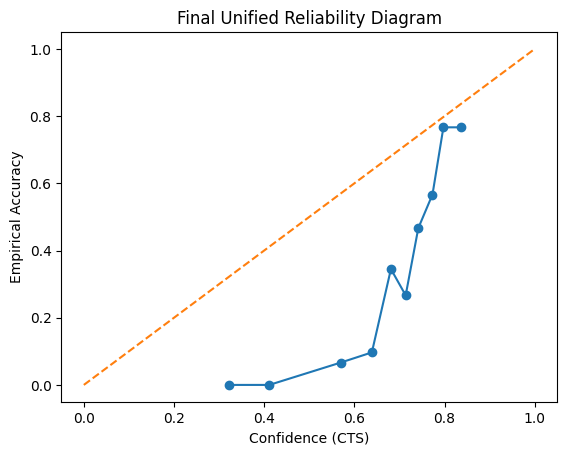

In [275]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    bin_stats["bin_confidence"],
    bin_stats["bin_accuracy"],
    marker="o"
)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Confidence (CTS)")
plt.ylabel("Empirical Accuracy")
plt.title("Final Unified Reliability Diagram")
plt.show()

In [265]:
# Expected Calibration Error (ECE)

In [276]:
ece = 0
N = len(final_unified_df)

for _, row in bin_stats.iterrows():
    ece += (row["bin_size"] / N) * abs(
        row["bin_accuracy"] - row["bin_confidence"]
    )

print("Final Quantile ECE:", round(ece, 4))

Final Quantile ECE: 0.3151
